# W4 EDA — Dataset Training-Readiness Audit

**data morph** (AI Builders 2026). Goal: confirm the 800-pair teacher dataset is
balanced and healthy for LoRA fine-tuning of Gemma 2B, and flag any risks
(imbalance, leakage, sequence-length) **before** W5.

Source: `data/interim/*__gen_*.json` (800 verified pairs) and
`data/processed/{train,val,test}.jsonl` (the chat-formatted splits).

> Diagnostic audit only — teacher-behavior deep-dives and presentation charts are out of scope.

## 1. Setup & load

In [1]:
import sys, json, glob
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    # walk up until we find pyproject.toml
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('project root (pyproject.toml) not found')


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 30)
print('project root:', PROJECT_ROOT)

Matplotlib is building the font cache; this may take a moment.


project root: /Users/thatt/Dev/AI project/data-morph


In [2]:
# Load all 800 verified interim pairs into one row-per-pair DataFrame.
INTERIM = PROJECT_ROOT / 'data' / 'interim'
UC_SHORT = {
    'uc1_csv_to_json_nested': 'uc1', 'uc2_json_to_csv_flatten': 'uc2',
    'uc3_txt_log_to_csv': 'uc3', 'uc4_csv_to_txt_report': 'uc4',
    'uc5_schema_migration': 'uc5',
}

rows = []
for f in sorted(glob.glob(str(INTERIM / '*__gen_*.json'))):
    d = json.load(open(f))
    tu = d.get('teacher_usage') or {}
    sc = d.get('scores') or {}
    script = d['script']
    rows.append(dict(
        case_id=d['case_id'], use_case=d['use_case'], uc=UC_SHORT[d['use_case']],
        complexity=d['complexity'], input_format=d['input_format'],
        output_format=d['output_format'],
        script_chars=len(script), script_lines=script.count(chr(10)) + 1,
        analysis_chars=len(d['analysis']),
        envelope_chars=len(json.dumps(d['envelope'])),
        instruction_chars=len(d['instruction']), retries=d.get('retries', 0),
        format_validity=sc.get('format_validity'),
        schema_compliance=sc.get('schema_compliance'),
        loadability=sc.get('loadability'),
        content_accuracy=sc.get('content_accuracy'),
        out_tok=tu.get('output_tokens'), in_tok=tu.get('input_tokens'),
        cache_read=tu.get('cache_read_input_tokens'),
        cache_create=tu.get('cache_creation_input_tokens'),
    ))

df = pd.DataFrame(rows)
CX_ORDER = ['simple', 'medium', 'complex']
df['complexity'] = pd.Categorical(df['complexity'], categories=CX_ORDER, ordered=True)
print('loaded', len(df), 'pairs |', df['uc'].nunique(), 'use cases')
df.head(3)

loaded 800 pairs | 5 use cases


,case_id,use_case,uc,complexity,input_format,output_format,script_chars,script_lines,analysis_chars,envelope_chars,instruction_chars,retries,format_validity,schema_compliance,loadability,content_accuracy,out_tok,in_tok,cache_read,cache_create
0,uc1_csv_to_json_nested/gen_000000,uc1_csv_to_json_nested,uc1,simple,csv,json,1544,52,1151,1900,177,0,1.0,1.0,1.0,1.0,3729,4917,26341,13097
1,uc1_csv_to_json_nested/gen_000001,uc1_csv_to_json_nested,uc1,simple,csv,json,1683,56,982,1909,177,0,1.0,1.0,1.0,1.0,3414,4917,26327,13034
2,uc1_csv_to_json_nested/gen_000002,uc1_csv_to_json_nested,uc1,simple,csv,json,1719,56,1121,1903,177,0,1.0,1.0,1.0,1.0,4275,4917,26337,13129


In [3]:
# Load the chat-formatted splits; capture per-example content length.
PROCESSED = PROJECT_ROOT / 'data' / 'processed'


def load_split(name):
    recs = []
    for line in open(PROCESSED / f'{name}.jsonl'):
        msgs = json.loads(line)['messages']
        content = ''.join(m['content'] for m in msgs)
        recs.append(dict(split=name, n_msgs=len(msgs), content_chars=len(content),
                         serialized=json.dumps(msgs)))
    return pd.DataFrame(recs)


splits = {s: load_split(s) for s in ['train', 'val', 'test']}
split_df = pd.concat(splits.values(), ignore_index=True)
for s, sdf in splits.items():
    print(f'{s:5} n={len(sdf):4}  median_content_chars={int(sdf.content_chars.median())}')

train n= 650  median_content_chars=4116
val   n=  80  median_content_chars=4023
test  n=  70  median_content_chars=4309


## 2. Corpus balance

Design target: 160 pairs per use case, and a 400 / 280 / 100 → **400 / 280 / 120**
simple/medium/complex mix. Check that the collected data matches.

In [4]:
by_uc = df['uc'].value_counts().sort_index()
by_cx = df['complexity'].value_counts().reindex(CX_ORDER)
print('per use case:\n', by_uc.to_string())
print('\nper complexity:\n', by_cx.to_string())

crosstab = pd.crosstab(df['uc'], df['complexity'], margins=True)
crosstab = crosstab[CX_ORDER + ['All']]
crosstab

per use case:
 uc
uc1    160
uc2    160
uc3    160
uc4    160
uc5    160

per complexity:
 complexity
simple     400
medium     280
complex    120


complexity,simple,medium,complex,All
uc,,,,
uc1,80,56,24,160
uc2,80,56,24,160
uc3,80,56,24,160
uc4,80,56,24,160
uc5,80,56,24,160
All,400,280,120,800


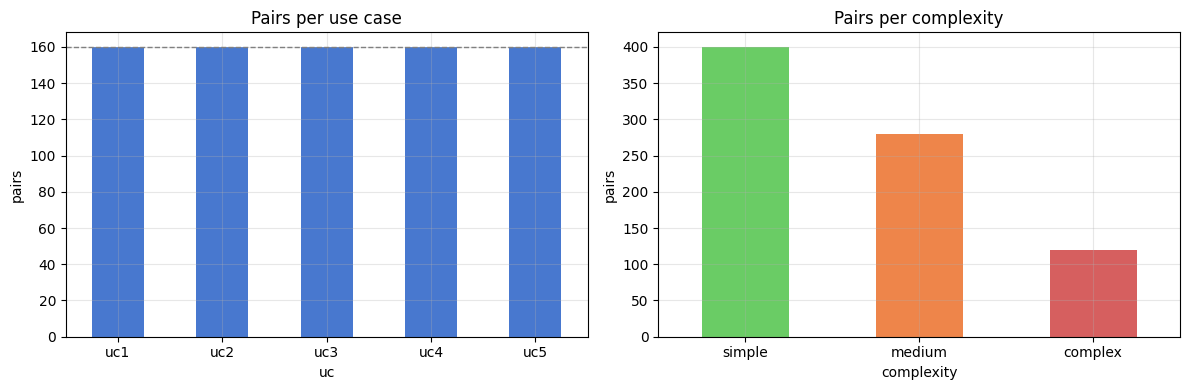

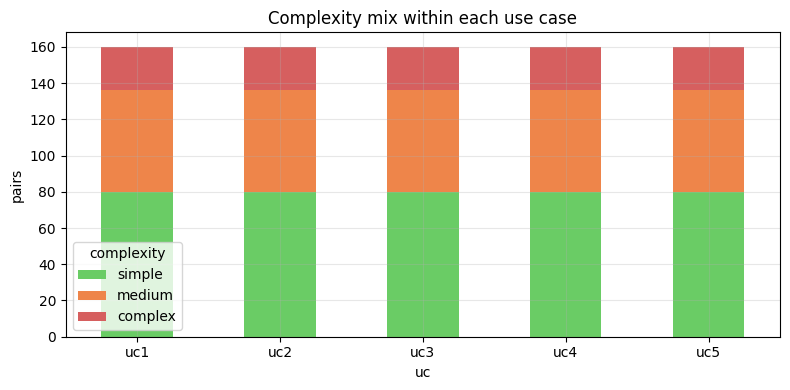

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_uc.plot.bar(ax=axes[0], color='#4878CF')
axes[0].set_title('Pairs per use case'); axes[0].set_ylabel('pairs')
axes[0].axhline(160, color='grey', ls='--', lw=1)
by_cx.plot.bar(ax=axes[1], color=['#6ACC65', '#EE854A', '#D65F5F'])
axes[1].set_title('Pairs per complexity'); axes[1].set_ylabel('pairs')
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

# UC x complexity stacked
ct = pd.crosstab(df['uc'], df['complexity'])[CX_ORDER]
ct.plot.bar(stacked=True, color=['#6ACC65', '#EE854A', '#D65F5F'], figsize=(8, 4))
plt.title('Complexity mix within each use case'); plt.ylabel('pairs')
plt.xticks(rotation=0); plt.legend(title='complexity'); plt.tight_layout(); plt.show()

## 3. Split integrity

Three checks: (a) split sizes, (b) **content-level leakage** between splits must be 0,
(c) are val/test representative of the corpus, or skewed in UC / complexity?

Note: the processed splits carry only `messages` (no labels), so UC/complexity
representativeness is inferred by matching each example's user-content back to its
source pair via the embedded envelope.

In [6]:
# (a) sizes  (b) leakage on exact serialized content
sets = {s: set(splits[s].serialized) for s in splits}
print('split sizes:', {s: len(v) for s, v in sets.items()})
print('leakage train&test:', len(sets['train'] & sets['test']))
print('leakage train&val :', len(sets['train'] & sets['val']))
print('leakage val&test  :', len(sets['val'] & sets['test']))
total_unique = len(sets['train'] | sets['val'] | sets['test'])
print('total unique examples:', total_unique, '(expect 800)')

split sizes: {'train': 650, 'val': 80, 'test': 70}
leakage train&test: 0
leakage train&val : 0
leakage val&test  : 0
total unique examples: 800 (expect 800)


In [7]:
# (c) map each split example back to its source pair to recover UC + complexity.
# Build a {script_text -> (uc, complexity)} lookup from the interim files; each
# split example embeds its script verbatim in the assistant message.
lookup = {}
for f in sorted(glob.glob(str(INTERIM / '*__gen_*.json'))):
    d = json.load(open(f))
    lookup[d['script']] = (UC_SHORT[d['use_case']], d['complexity'])


def tag_split(name):
    out = []
    for line in open(PROCESSED / f'{name}.jsonl'):
        msgs = json.loads(line)['messages']
        assistant = msgs[-1]['content']
        uc = cx = None
        for script, (u, c) in lookup.items():
            if script in assistant or assistant in script:
                uc, cx = u, c
                break
        out.append((name, uc, cx))
    return out


tagged = pd.DataFrame(
    [t for s in ['train', 'val', 'test'] for t in tag_split(s)],
    columns=['split', 'uc', 'complexity'],
)
matched = tagged['uc'].notna().mean()
print(f'matched {matched:.0%} of split examples back to a source pair')
tagged['complexity'] = pd.Categorical(tagged['complexity'], categories=CX_ORDER, ordered=True)

matched 100% of split examples back to a source pair


complexity share by split:
 complexity  simple  medium  complex
split                              
train         49.5    35.4     15.1
val           56.2    32.5     11.2
test          41.4    38.6     20.0


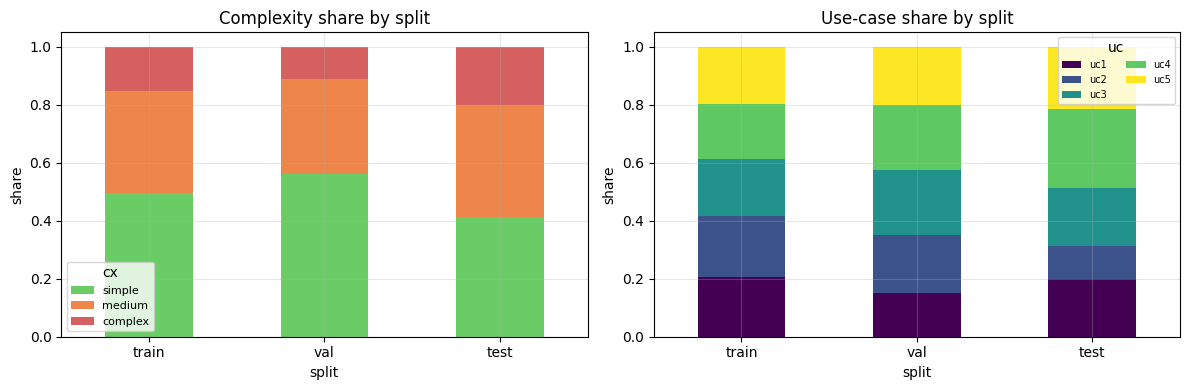

In [8]:
# complexity share within each split vs the corpus baseline
share_cx = (pd.crosstab(tagged['split'], tagged['complexity'], normalize='index')
            .reindex(['train', 'val', 'test'])[CX_ORDER])
print('complexity share by split:\n', (share_cx * 100).round(1).to_string())

share_uc = pd.crosstab(tagged['split'], tagged['uc'], normalize='index').reindex(['train', 'val', 'test'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
share_cx.plot.bar(stacked=True, ax=axes[0], color=['#6ACC65', '#EE854A', '#D65F5F'])
axes[0].set_title('Complexity share by split'); axes[0].set_ylabel('share')
axes[0].tick_params(axis='x', rotation=0); axes[0].legend(title='cx', fontsize=8)
share_uc.plot.bar(stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Use-case share by split'); axes[1].set_ylabel('share')
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(title='uc', fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 4. Length distributions

The student learns to emit the **script** (and analysis) from the **envelope**.
Outliers here drive sequence length and can stress a small model's context.

In [9]:
length_cols = ['script_chars', 'script_lines', 'analysis_chars', 'envelope_chars', 'instruction_chars']
df[length_cols].describe().round(1)

,script_chars,script_lines,analysis_chars,envelope_chars,instruction_chars
count,800.0,800.0,800.0,800.0,800.0
mean,1314.0,46.2,915.3,1328.4,146.0
std,395.0,10.7,135.3,619.1,22.2
min,629.0,24.0,603.0,749.0,113.0
25%,902.8,38.0,818.0,810.0,135.0
50%,1372.0,47.0,897.0,1212.5,140.0
75%,1641.0,53.0,1004.0,1389.0,163.0
max,2545.0,96.0,1353.0,3203.0,177.0


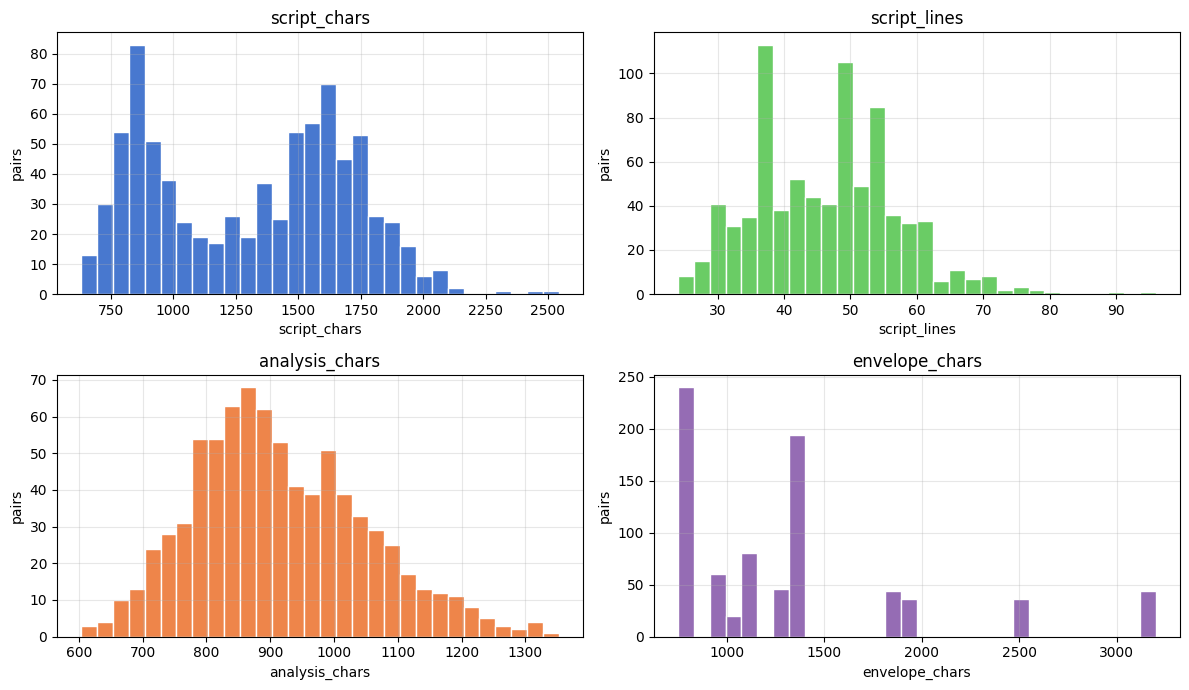

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col, color in zip(
    axes.ravel(),
    ['script_chars', 'script_lines', 'analysis_chars', 'envelope_chars'],
    ['#4878CF', '#6ACC65', '#EE854A', '#956CB4'],
):
    ax.hist(df[col], bins=30, color=color, edgecolor='white')
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('pairs')
plt.tight_layout(); plt.show()

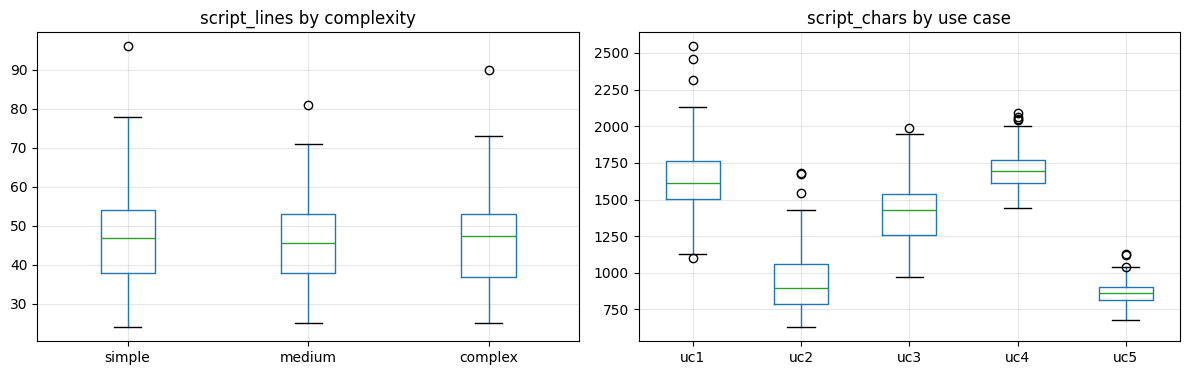

In [11]:
# script size by complexity and by use case
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column='script_lines', by='complexity', ax=axes[0])
axes[0].set_title('script_lines by complexity'); axes[0].set_xlabel('')
df.boxplot(column='script_chars', by='uc', ax=axes[1])
axes[1].set_title('script_chars by use case'); axes[1].set_xlabel('')
plt.suptitle(''); plt.tight_layout(); plt.show()

## 5. Sequence-length proxy (fine-tune context budget)

Each training example is `user(envelope+instruction)` + `assistant(analysis+script)`.
We approximate token count as **chars / 4** (a standard rough heuristic — not the real
Gemma tokenizer, so treat as indicative). Goal: confirm examples fit a typical
fine-tune `max_seq_len` (commonly 1024 / 2048 / 4096).

In [12]:
CHARS_PER_TOKEN = 4.0
split_df['approx_tokens'] = (split_df['content_chars'] / CHARS_PER_TOKEN).round().astype(int)
summary = split_df.groupby('split')['approx_tokens'].agg(['median', 'mean', 'max']).round(0)
summary = summary.reindex(['train', 'val', 'test'])
print(summary.to_string())

for thr in (1024, 2048, 4096):
    frac = (split_df['approx_tokens'] <= thr).mean()
    print(f'examples within {thr:>4} tokens: {frac:6.1%}')

       median    mean   max
split                      
train  1029.0  1124.0  2094
val    1006.0  1089.0  1842
test   1078.0  1147.0  1912
examples within 1024 tokens:  49.8%
examples within 2048 tokens:  99.9%
examples within 4096 tokens: 100.0%


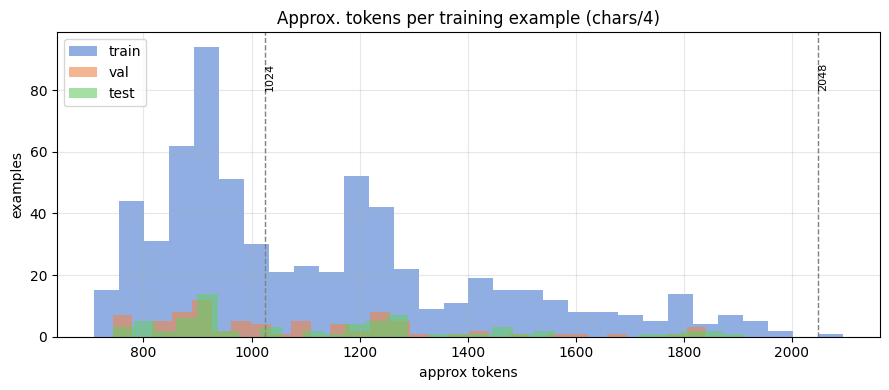

In [13]:
plt.figure(figsize=(9, 4))
for s, color in zip(['train', 'val', 'test'], ['#4878CF', '#EE854A', '#6ACC65']):
    plt.hist(split_df.loc[split_df.split == s, 'approx_tokens'], bins=30,
             alpha=0.6, label=s, color=color)
for thr in (1024, 2048):
    plt.axvline(thr, color='grey', ls='--', lw=1)
    plt.text(thr, plt.ylim()[1] * 0.9, f'{thr}', rotation=90, va='top', fontsize=8)
plt.title('Approx. tokens per training example (chars/4)')
plt.xlabel('approx tokens'); plt.ylabel('examples'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Quality & retries

Every pair passed the acceptance bar (FV/SC/LD = 1.0, CA >= 0.95). Confirm, then
look at retries — which cases were hardest for the teacher to get right.

In [14]:
metric_cols = ['format_validity', 'schema_compliance', 'loadability', 'content_accuracy']
print('metric means (expect ~1.0):')
print(df[metric_cols].mean().round(4).to_string())
print('\nany pair below the bar?')
below = df[(df.format_validity < 1) | (df.schema_compliance < 1) | (df.loadability < 1) | (df.content_accuracy < 0.95)]
print(f'  {len(below)} pairs below bar')

print('\nretry distribution:')
print(df['retries'].value_counts().sort_index().to_string())

metric means (expect ~1.0):
format_validity      1.0
schema_compliance    1.0
loadability          1.0
content_accuracy     1.0

any pair below the bar?
  0 pairs below bar

retry distribution:
retries
0    786
1     14


14 pairs needed >=1 retry

retries by use case:
uc
uc1    3
uc2    3
uc3    3
uc4    3
uc5    2

retries by complexity:
complexity
simple     11
medium      2
complex     1


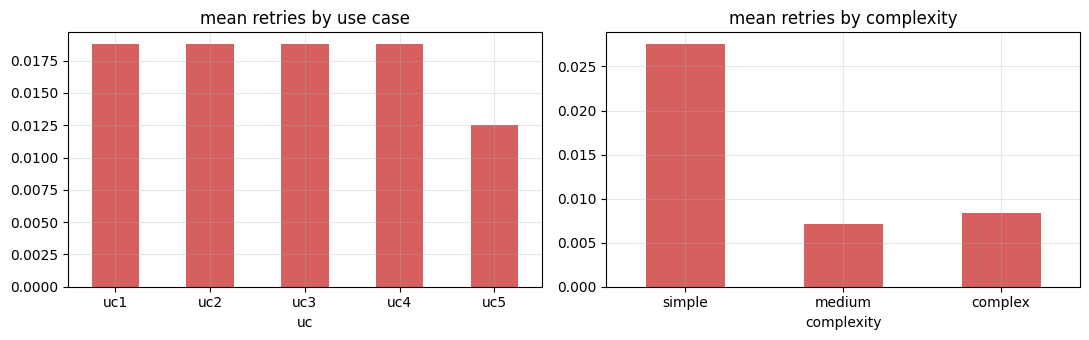

In [15]:
retried = df[df.retries > 0]
print(f'{len(retried)} pairs needed >=1 retry')
if len(retried):
    print('\nretries by use case:'); print(retried.groupby('uc').size().to_string())
    print('\nretries by complexity:'); print(retried.groupby('complexity', observed=True).size().to_string())
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    df.groupby('uc')['retries'].mean().plot.bar(ax=axes[0], color='#D65F5F')
    axes[0].set_title('mean retries by use case'); axes[0].tick_params(axis='x', rotation=0)
    df.groupby('complexity', observed=True)['retries'].mean().reindex(CX_ORDER).plot.bar(ax=axes[1], color='#D65F5F')
    axes[1].set_title('mean retries by complexity'); axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout(); plt.show()

## 7. Teacher cost (Opus token usage)

What the corpus cost to generate, and where the spend concentrated. Output tokens
are the meaningful generation cost; cache-read tokens reflect the shared skill prompt.

corpus token totals:
  out_tok        1,692,760
  in_tok         3,979,001
  cache_read    23,153,253
  cache_create   10,291,378

mean output tokens / pair: 2116


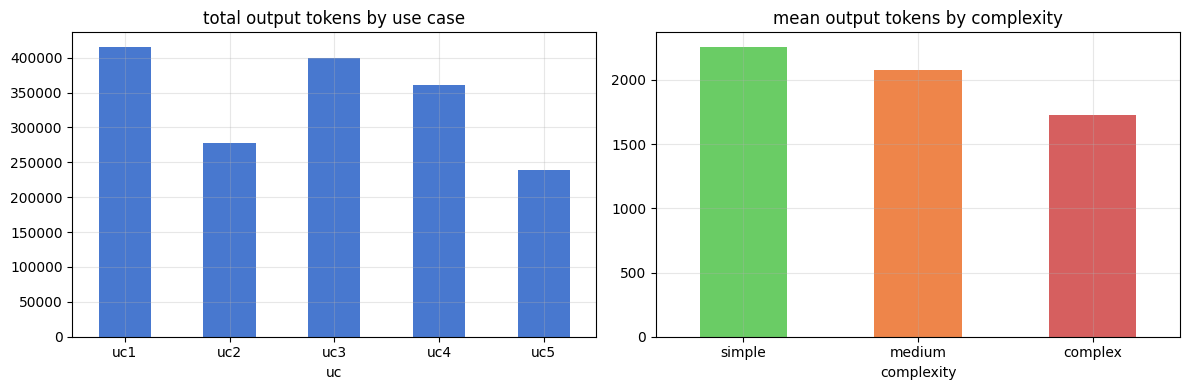

In [16]:
tok_cols = ['out_tok', 'in_tok', 'cache_read', 'cache_create']
totals = df[tok_cols].sum()
print('corpus token totals:')
for c in tok_cols:
    print(f'  {c:11} {int(totals[c]):>12,}')
print(f'\nmean output tokens / pair: {df.out_tok.mean():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('uc')['out_tok'].sum().plot.bar(ax=axes[0], color='#4878CF')
axes[0].set_title('total output tokens by use case'); axes[0].tick_params(axis='x', rotation=0)
df.groupby('complexity', observed=True)['out_tok'].mean().reindex(CX_ORDER).plot.bar(
    ax=axes[1], color=['#6ACC65', '#EE854A', '#D65F5F'])
axes[1].set_title('mean output tokens by complexity'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 8. Readiness verdict

Programmatic green/amber checklist for entering W5 fine-tuning.

In [17]:
checks = []


def check(name, ok, detail):
    checks.append((ok, name, detail))


check('use-case balance', (df['uc'].value_counts() == 160).all(),
      f"counts={df['uc'].value_counts().sort_index().to_dict()}")
check('complexity mix 400/280/120',
      df['complexity'].value_counts().reindex(CX_ORDER).tolist() == [400, 280, 120],
      str(df['complexity'].value_counts().reindex(CX_ORDER).to_dict()))
check('zero split leakage',
      len(sets['train'] & sets['test']) == 0 and len(sets['train'] & sets['val']) == 0
      and len(sets['val'] & sets['test']) == 0, 'pairwise intersections all empty')
check('all 800 examples unique + accounted', total_unique == 800, f'unique={total_unique}')
check('all pairs pass quality bar', len(below) == 0, f'{len(below)} below bar')
check('examples fit 2048-token budget', (split_df['approx_tokens'] <= 2048).mean() == 1.0,
      f"max approx tokens={int(split_df['approx_tokens'].max())}")
check('val/test complexity within 10pts of corpus',
      bool((share_cx.sub([400/800, 280/800, 120/800], axis=1).abs() <= 0.10).all().all()),
      'per-split complexity share close to corpus')

print('W5 readiness checklist')
print('=' * 60)
for ok, name, detail in checks:
    mark = 'PASS' if ok else 'CHECK'
    print(f'[{mark}] {name}')
    print(f'        {detail}')
n_pass = sum(ok for ok, _, _ in checks)
print('=' * 60)
print(f'{n_pass}/{len(checks)} checks green')

W5 readiness checklist
[PASS] use-case balance
        counts={'uc1': 160, 'uc2': 160, 'uc3': 160, 'uc4': 160, 'uc5': 160}
[PASS] complexity mix 400/280/120
        {'simple': 400, 'medium': 280, 'complex': 120}
[PASS] zero split leakage
        pairwise intersections all empty
[PASS] all 800 examples unique + accounted
        unique=800
[PASS] all pairs pass quality bar
        0 below bar
[CHECK] examples fit 2048-token budget
        max approx tokens=2094
[PASS] val/test complexity within 10pts of corpus
        per-split complexity share close to corpus
6/7 checks green


### Takeaways

Read the printed checklist above for the live verdict. Expected state: dataset is
balanced (160/UC, 400/280/120), splits are disjoint and representative, and every
example fits a small fine-tune context budget — i.e. **ready for W5 LoRA fine-tuning**
on `data/processed/train.jsonl`, evaluated on `test.jsonl` with the four W2 metrics.